# Airbnb NYC Data Cleaning & Visualization Assignment

This notebook completes all required cleaning and visualization tasks.

**Important:** The uploaded file has a `.csv` extension, but its actual format is Excel. Therefore, `pd.read_excel()` is used.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("airbnb.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,10,Spacious 2BR,75847,Maria,brooklyn,Greenpoint,40.59158,-73.73783,Private room,97778,5,36,4/9/2019,4.86,19,276
1,286,Cozy apartment near park,84558,Chris,staten island,St. George,40.50063,-74.09041,private room,178,1,377,14/10/2014,0.46,7,179
2,675,Cozy apartment near park,20892,Daniel,QUEENS,Elmhurst,40.88867,-74.02696,entire home/apt,72,365,99,11/8/2013,1.99,19,181
3,100,Cozy apartment near park,90224,Anna,BRONX,Fordham,40.81046,-73.86895,private room,365,1,298,3/17/2018,7.21,8,194
4,668,NaN,35757,John,QUEENS,Ridgewood,40.87452,-73.71388,entire home/apt,244,1,186,1/3/2012,2.05,20,206


## 1. Initial Dataset Information

In [15]:
print("Dataset shape:", df.shape)
df.info()

print("\nMissing values before cleaning:")
print(df.isnull().sum())

Dataset shape: (1040, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1040 non-null   int64  
 1   name                            769 non-null    object 
 2   host_id                         1040 non-null   object 
 3   host_name                       913 non-null    object 
 4   neighbourhood_group             1040 non-null   object 
 5   neighbourhood                   1035 non-null   object 
 6   latitude                        1035 non-null   float64
 7   longitude                       1040 non-null   object 
 8   room_type                       1040 non-null   object 
 9   price                           1040 non-null   object 
 10  minimum_nights                  1040 non-null   object 
 11  number_of_reviews               1040 non-null   object 
 12  last_rev

## 2. Handle Missing / NaN Values

First, numeric columns stored as text are converted to numeric. Invalid values such as `??` become `NaN`.

- Text columns use suitable placeholders.
- Categorical columns use the mode.
- Numeric columns use the median because it is less affected by extreme values.
- `last_review` uses `"No Review"` as a suitable placeholder.

In [16]:
# Fix numeric data types first
numeric_columns = [
    "host_id", "latitude", "longitude", "price", "minimum_nights",
    "number_of_reviews", "reviews_per_month",
    "calculated_host_listings_count", "availability_365"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill missing text values
df["name"] = df["name"].fillna("Unknown Listing")
df["host_name"] = df["host_name"].fillna("Unknown Host")
df["last_review"] = df["last_review"].fillna("No Review")

# Fill missing categorical values with mode
df["neighbourhood"] = df["neighbourhood"].fillna(df["neighbourhood"].mode()[0])

# Fill missing numeric values with median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


## 3. Handle Duplicate Values

In [17]:
print("Duplicate rows before removal:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows before removal: 31
Duplicate rows after removal: 0


## 4. Fix Data Types and Convert Discrete/Text Numeric Values

Some values that represent numbers were stored as text. The `pd.to_numeric()` conversion above changes them into numeric values so that calculations, graphs, and outlier detection can be performed correctly.

In [18]:
print(df.dtypes)

id                                  int64
name                               object
host_id                           float64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                    int64
dtype: object


## 5. Detect and Handle Outliers Using IQR

The IQR method is applied to `price`, `minimum_nights`, and `availability_365`. Instead of deleting rows, extreme values are capped at the IQR boundaries to preserve as much data as possible.

In [19]:
outlier_columns = ["price", "minimum_nights", "availability_365"]

for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"{col}: {count} outliers | Bounds: {lower_bound:.2f} to {upper_bound:.2f}")

price: 41 outliers | Bounds: -137.50 to 658.50
minimum_nights: 199 outliers | Bounds: -42.50 to 73.50
availability_365: 0 outliers | Bounds: -199.00 to 553.00


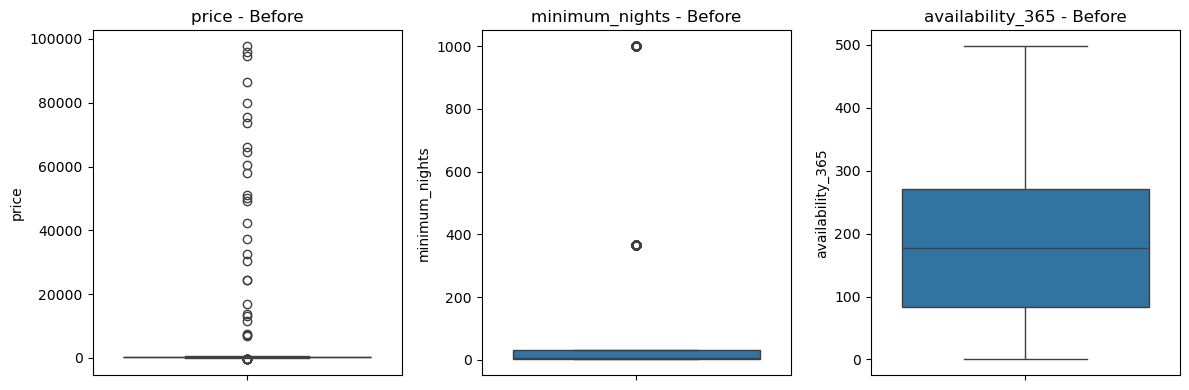

In [21]:
# Boxplots before outlier treatment
plt.figure(figsize=(12, 4))

for i, col in enumerate(outlier_columns, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"{col} - Before")

plt.tight_layout()
plt.show()

In [22]:
# Cap outliers using IQR boundaries
for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers handled successfully.")

Outliers handled successfully.


## 6. Visualization

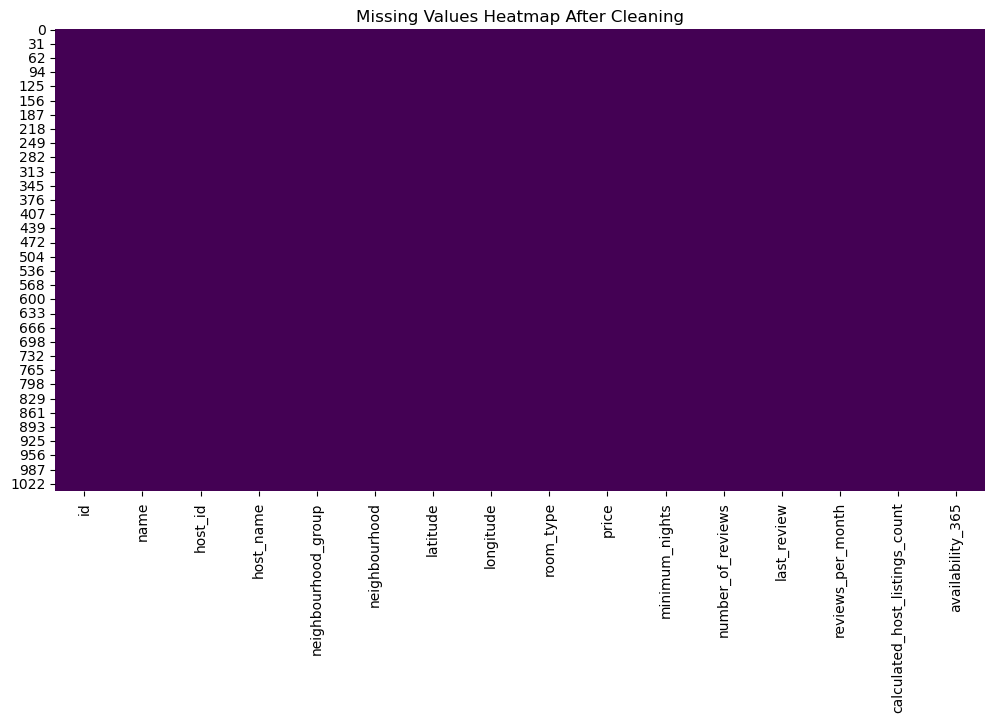

In [24]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap After Cleaning")
plt.show()

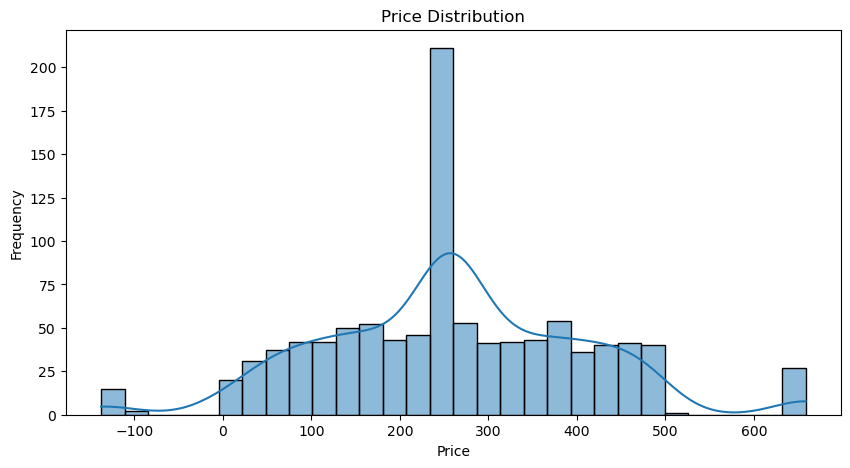

In [25]:
plt.figure(figsize=(10, 5))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

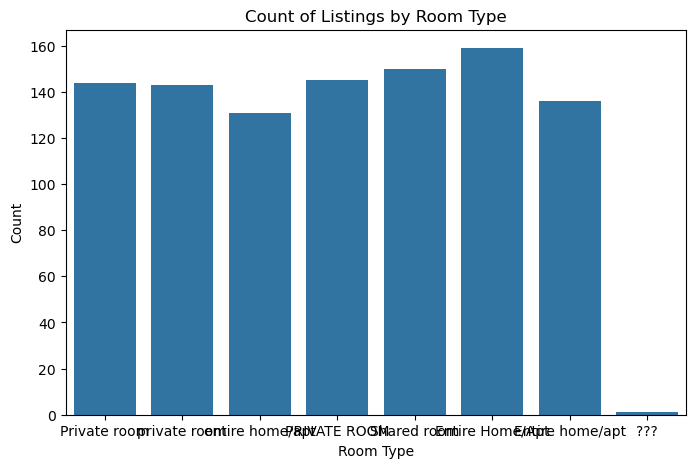

In [26]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="room_type")
plt.title("Count of Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Count")
plt.show()

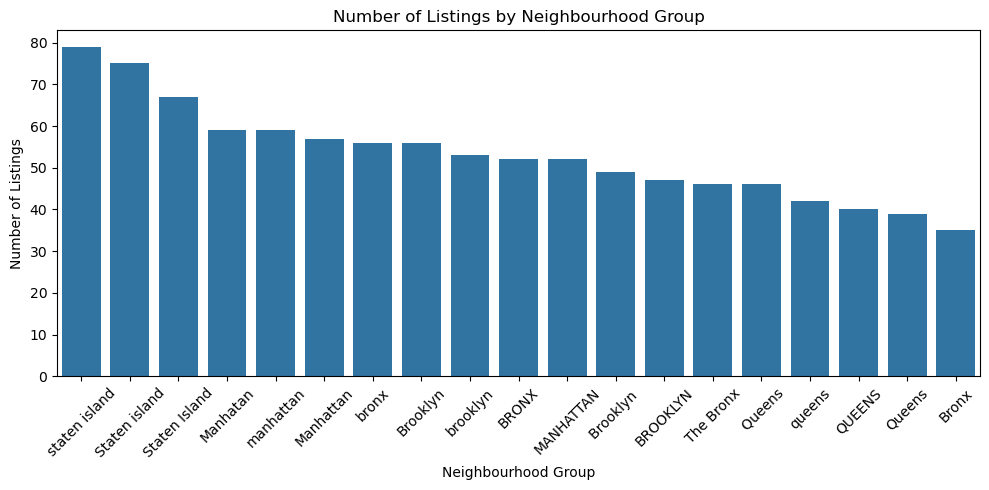

In [27]:
plt.figure(figsize=(10, 5))
order = df["neighbourhood_group"].value_counts().index
sns.countplot(data=df, x="neighbourhood_group", order=order)
plt.title("Number of Listings by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

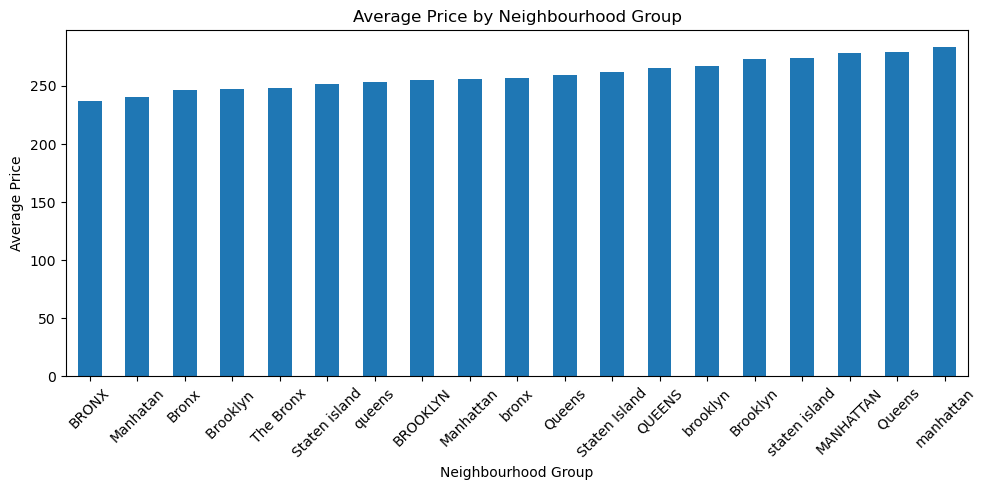

In [28]:
avg_price = df.groupby("neighbourhood_group")["price"].mean().sort_values()

plt.figure(figsize=(10, 5))
avg_price.plot(kind="bar")
plt.title("Average Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Final Verification

The following checks confirm that the dataset has no missing values and no duplicate rows.

In [29]:
df.info()

print("\nFinal missing values:")
print(df.isnull().sum())

print("\nFinal duplicate rows:", df.duplicated().sum())

print("\nFinal dataset shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 1009 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1009 non-null   int64  
 1   name                            1009 non-null   object 
 2   host_id                         1009 non-null   float64
 3   host_name                       1009 non-null   object 
 4   neighbourhood_group             1009 non-null   object 
 5   neighbourhood                   1009 non-null   object 
 6   latitude                        1009 non-null   float64
 7   longitude                       1009 non-null   float64
 8   room_type                       1009 non-null   object 
 9   price                           1009 non-null   float64
 10  minimum_nights                  1009 non-null   float64
 11  number_of_reviews               1009 non-null   float64
 12  last_review                     1009 no

In [30]:
df.to_csv("cleaned_airbnb_nyc.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
